In [154]:
%matplotlib inline
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import random
import pandas as pd
import itertools
import math
from matplotlib.colors import LogNorm
import time
#from numpy.random import *
#import numexpr as ne
from IPython.display import clear_output
import os
import sys
import warnings
warnings.filterwarnings('ignore')
#from google.colab import drive
#drive.mount('/content/drive')

In [155]:
data1=pd.read_csv( 'Si_Thermo_2thome_01.csv', encoding='shift_jis' , skipinitialspace=True )
data1

,Axis (deg),I(cts)
0,68.5889,23
1,68.5989,25
2,68.6089,28
3,68.6189,20
4,68.6289,39
...,...,...
196,70.5489,143
197,70.5589,117
198,70.5689,115
199,70.5789,109


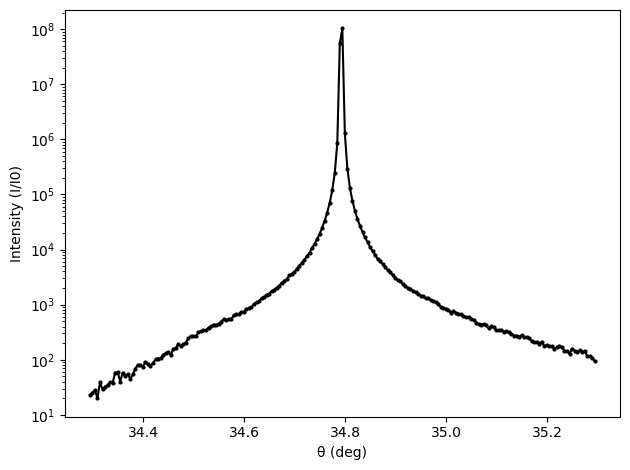

In [156]:
#データをplot
lam = 1.55  # Å
two_theta = data1.iloc[:,0].to_numpy()   # 2θ       
y  = data1.iloc[:,1].to_numpy()  
#I0 = data1.iloc[:,2].to_numpy()  # I0
#atten = 5000

#I_corr = y / (np.maximum(I0, 1e-12) * np.maximum(atten, 1e-12))

theta = two_theta / 2.0
q_data = (2*np.pi/lam) * np.sin(np.deg2rad(theta))  # q [1/Å] = (2π/λ) sinθ

plt.plot(theta, y, 'ko-', ms=2)  #k，黑色 o显示圆点，实线链接用o-，ms=粗细度  theta---q可以转换
plt.yscale('log')
plt.xlabel('θ (deg)'); plt.ylabel('Intensity (I/I0)')
plt.tight_layout()
plt.show()

In [157]:
y

array([       23,        25,        28,        20,        39,        29,
              32,        35,        39,        38,        58,        60,
              40,        58,        51,        54,        45,        54,
              69,        81,        79,        74,        92,        83,
              78,        86,       102,       105,       106,       123,
             131,       138,       121,       155,       163,       191,
             177,       191,       205,       245,       268,       264,
             265,       315,       328,       340,       343,       383,
             406,       435,       425,       446,       492,       547,
             518,       552,       545,       637,       667,       664,
             736,       744,       834,       871,       897,      1028,
            1104,      1167,      1299,      1376,      1522,      1568,
            1767,      1871,      2028,      2191,      2484,      2698,
            2890,      3384,      3609,      3887, 

In [158]:
#CTR MODEL 04-

def CTRmodel04( q_data, I0, a, mu, aS, NS ):
    #
    # exp_sum= 0j + 0
    #exp_sum = np.zeros_like( q_data, dtype=np.complex128 )
    exp_sum = 0j+0    
    #
    for n_ in range(int(NS)+1):
        exp_sum += np.exp( - n_* mu ) * np.exp( 1j * q_data * aS * n_ )
    #
    exp_sum += 1 / ( np.sqrt(2) * np.sin( q_data * a / 2 ) )
    #
    Iq_ = 10**I0 * abs( exp_sum )**2
    #
    return Iq_

In [159]:
# 归一化数据强度
#y = y / np.max(y)*1e10

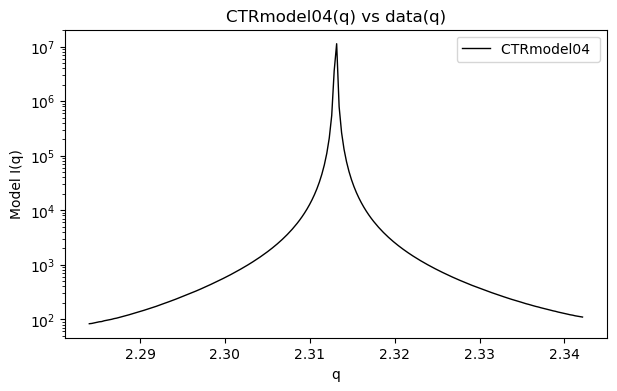

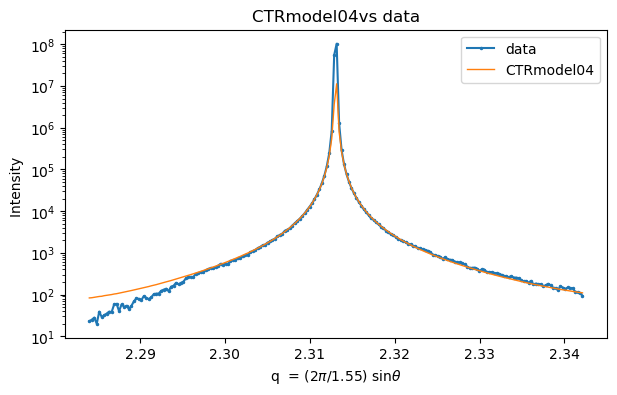

array([8.34904163e+01, 8.49890426e+01, 8.65836239e+01, 8.82780802e+01,
       9.00765275e+01, 9.19832913e+01, 9.40029193e+01, 9.61401968e+01,
       9.84001620e+01, 1.00788123e+02, 1.03309676e+02, 1.05970726e+02,
       1.08777506e+02, 1.11736604e+02, 1.14854982e+02, 1.18140011e+02,
       1.21599493e+02, 1.25241697e+02, 1.29075393e+02, 1.33109890e+02,
       1.37355074e+02, 1.41821460e+02, 1.46520231e+02, 1.51463301e+02,
       1.56663368e+02, 1.62133976e+02, 1.67889591e+02, 1.73945674e+02,
       1.80318766e+02, 1.87026581e+02, 1.94088109e+02, 2.01523726e+02,
       2.09355324e+02, 2.17606443e+02, 2.26302427e+02, 2.35470595e+02,
       2.45140424e+02, 2.55343762e+02, 2.66115063e+02, 2.77491644e+02,
       2.89513979e+02, 3.02226025e+02, 3.15675591e+02, 3.29914746e+02,
       3.45000292e+02, 3.60994282e+02, 3.77964620e+02, 3.95985733e+02,
       4.15139342e+02, 4.35515335e+02, 4.57212765e+02, 4.80340998e+02,
       5.05021031e+02, 5.31387002e+02, 5.59587946e+02, 5.89789820e+02,
      

In [160]:
# --- パラメータ---
a  = 5.4328       # Å (Si 格子定数)
aS = 5.55         # Å (表面层，格子定数 a)
mu = 7.7598e-6             # 衰减係数
NS = 11            # 层数；層数
I0 = 0.261433          # 振幅标定
bg = 10            # back ground背景

I_model = CTRmodel04(q_data, I0, a, mu, aS, NS)+bg
#I_model_norm  = I_model / np.max(I_model)  *1e10  # 模型输出也进行归一化
#I_model_int = np.asarray(I_model_norm, dtype = int)
I_model_int = np.asarray(I_model, dtype = int)
#I_model = (lambda v: v/np.maximum(np.nanmax(v), 1e-12))(CTRmodel04(q_data, I0, a, mu, aS, NS))

#a2  = 5.432   # Å (Si 晶格常数)
#aS2 = 5.528  # Å (表面层间距，示例同 a)
#mu2 = 4.60E-3    # 衰减係数
#NS2 = 120000     # 层数；層数
#I02 = -7.229     # 振幅标定

#I_model2 = CTRmodel04(q_data, I02, a2, mu2, aS2, NS2)
#I_model2 = (lambda v: v/np.maximum(np.nanmax(v), 1e-12))(CTRmodel04(q_data, I02, a2, mu2, aS2, NS2))

# --- plot ---
plt.figure(figsize=(7,4))
#plt.plot(q_data, y, '-', lw=1,label='data')
plt.plot(q_data, I_model_int, 'k-', lw=1,label='CTRmodel04 ')
plt.yscale('log') 
plt.xlabel(r'q')
plt.ylabel('Model I(q)')
plt.title('CTRmodel04(q) vs data(q)')
plt.legend()
plt.show()

#----比较----
plt.figure(figsize=(7,4))
plt.plot(q_data, y, '.-', ms=3, label='data')
plt.plot(q_data, I_model_int, '-', lw=1, label='CTRmodel04')
plt.yscale('log')  
plt.xlabel(r'q  = (2$\pi$/1.55) sin$\theta$')
plt.ylabel('Intensity ')
plt.title('CTRmodel04vs data')
plt.legend()
plt.show()
I_model

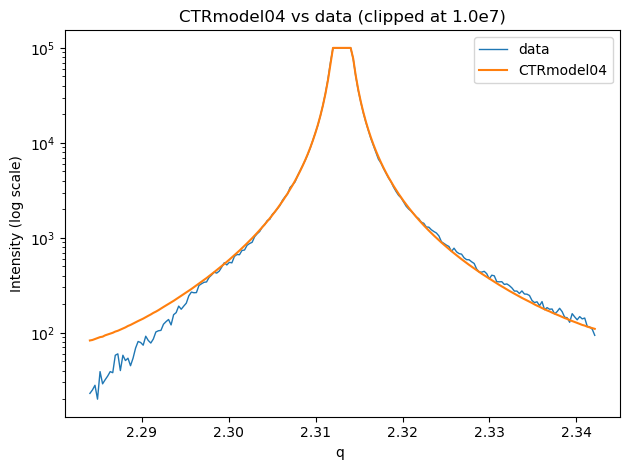

In [161]:
q = q_data            # 横轴
y_data = y           # 实验data
y_fit  = I_model_int# 模型（或平均参数 mean_p）
#########------------------------------###
y_cut   = 1.0e5        # 上限

# ==== 对 data 和 model 同时截断（用于作图）====
y_data_cut = np.clip(y_data, None,  y_cut)
y_fit_cut  = np.clip(y_fit,  None,  y_cut)

# ==== 作图（对数 y 轴）====

plt.plot(q, y_data_cut, label="data", lw=1.0)
plt.plot(q, y_fit_cut,  label="CTRmodel04", lw=1.5)
plt.yscale("log")
plt.xlabel(r"q ")  # 若用 θ 轴就写 θ (deg)
plt.ylabel("Intensity (log scale)")
plt.title("CTRmodel04 vs data (clipped at 1.0e7)")
plt.legend()
plt.tight_layout()
plt.show()

In [162]:
def CTRmodel04fit(q_data ,num_temp,_p_):
    result = np.zeros((num_temp, len(q_data)))
    for i in range(num_temp):
        result[i,:] = CTRmodel04(
            q_data,
            _p_[i, 0],  # I0
            _p_[i, 1],  # a
            _p_[i, 2],  # mu
            _p_[i, 3],  # aS
            _p_[i, 4]   # NS
        )
    return result

In [163]:
#def CTRmodel04fit(q_data ,num_temp,_p_):
#    _I0_ = _p_[:,0].reshape(num_temp,1)
#    _a_ = _p_[:,1].reshape(num_temp,1)
#    _mu_ = _p_[:,2].reshape(num_temp,1)
#    _aS_ = _p_[:,3].reshape(num_temp,1)
#   _bg_ = _p_[:,4].reshape(num_temp,1)

    ##################
    
#    y =  CTRmodel04(q_data, _I0_, _a_, _mu_, _aS_, NS)+_bg_
    ####################
    
    # y = (lambda v: v/np.maximum(np.nanmax(v), 1e-12))(CTRmodel04(q, I0, a, mu, aS, NS))
#    return y

In [164]:
# 擬似フォークト2つによるピークフィット
# メトロポリス法によるパラメータ更新
#ポアソンノイズ
def update_param_p(i,E,n,sigma_R,q_data,y,const,_p_,ratio_p,rslt_p,_rslt_p0_,_rslt_p1_,_rslt_p2_,_rslt_p3_,_rslt_p4_,stepsize_p0,stepsize_p1,stepsize_p2,stepsize_p3,stepsize_p4,
                _ratio_p_,num_temp,num_para,_p_min_,_p_max_,burn_in_length):
    #num_para = np.size(_p_max_)
    # temp=0はprior（事前分布）に基づいてサンプリング
    _p_[0,0] = (_p_max_[0]-_p_min_[0])*np.random.rand()+_p_min_[0]
    _p_[0,1] = (_p_max_[1]-_p_min_[1])*np.random.rand()+_p_min_[1]
    _p_[0,2] = (_p_max_[2]-_p_min_[2])*np.random.rand()+_p_min_[2]
    _p_[0,3] = (_p_max_[3]-_p_min_[3])*np.random.rand()+_p_min_[3]
    _p_[0,4] = (_p_max_[4]-_p_min_[4])*np.random.rand()+_p_min_[4]

    for _ii_ in range(num_para):
        _select_ = np.random.randint(0,num_para,num_temp) #パラメータ間の相関がサンプリングに影響しないようにランダムにパラメータ選択して更新。
        #_select_ = np.int(_ii_)*np.ones(num_temp,dtype="int8") # 順番にパラメータ更新する場合
        _next_p_ = 1*_p_
        for _j_ in range(1,num_temp):# temp=0は別のサンプリングを行う
            _ratio_p_[num_para*_j_+_select_[_j_]] = np.append(_ratio_p_[num_para*_j_+_select_[_j_]],0)
            if(_select_[_j_]==0):
                _next_p_[_j_,0] += stepsize_p0[_j_]*(2*np.random.rand()-1)
            if(_select_[_j_]==1):
                _next_p_[_j_,1] += stepsize_p1[_j_]*(2*np.random.rand()-1)
            if(_select_[_j_]==2):
                _next_p_[_j_,2] += stepsize_p2[_j_]*(2*np.random.rand()-1)
            if(_select_[_j_]==3):
                _next_p_[_j_,3] += stepsize_p3[_j_]*(2*np.random.rand()-1)
            if(_select_[_j_]==4):
                _next_p_[_j_,4] += stepsize_p4[_j_]*(2*np.random.rand()-1)
        _y_ = CTRmodel04fit(q_data ,num_temp,_next_p_)
        # ガウスノイズ
        #next_E = 1/2/n/sigma_R**2*np.linalg.norm(y-(
        #         _y_                                                                                                                
        #         ),axis=1)**2
        ########添加#######
        # 削峰
        y_cut = 1e5
        _y_ = np.clip(_y_, None, y_cut)
        y    = np.clip(y,   None, y_cut)
        
        # 屏蔽峰值区间
        q_mask = (q_data > 2.311999) & (q_data < 2.314032)
        valid_idx = ~q_mask
        _y_ = _y_[:, valid_idx]
        
        #########添加######
        # ポアソンノイズ
        next_E = 1/n/sigma_R**2*(np.sum(_y_-np.log(_y_)*y,axis=1)+const)
        
        prob = np.exp(-n*temp*(next_E-E)) - np.random.rand(num_temp)
        J = np.where(prob>0)
        for _jj_ in J[0]:
            if(_p_min_[_select_[_jj_]]<= _next_p_[_jj_,_select_[_jj_]]<=_p_max_[_select_[_jj_]]):
                _p_[_jj_,_select_[_jj_]] = _next_p_[_jj_,_select_[_jj_]]
                E[_jj_] = next_E[_jj_]
                if(_jj_>0):
                    (_ratio_p_[num_para*_jj_+_select_[_jj_]])[-1] +=1#採択率についての履歴を残す
                if(i>burn_in_length):
                    ratio_p[_jj_,_select_[_jj_]] += 1#採択率そのもの
        rslt_p[_select_[num_temp-1]] = np.append(rslt_p[_select_[num_temp-1]],_p_[num_temp-1,_select_[num_temp-1]])#最低温の履歴
        for _kk_ in range(1,num_temp):#全レプリカのサンプリング履歴を残す
            if(_select_[_kk_]==0):
                _rslt_p0_[_kk_] = np.append(_rslt_p0_[_kk_],_p_[_kk_,0])
            if(_select_[_kk_]==1):
                _rslt_p1_[_kk_] = np.append(_rslt_p1_[_kk_],_p_[_kk_,1])
            if(_select_[_kk_]==2):
                _rslt_p2_[_kk_] = np.append(_rslt_p2_[_kk_],_p_[_kk_,2])
            if(_select_[_kk_]==3):
                _rslt_p3_[_kk_] = np.append(_rslt_p3_[_kk_],_p_[_kk_,3])
            if(_select_[_kk_]==4):
                _rslt_p4_[_kk_] = np.append(_rslt_p4_[_kk_],_p_[_kk_,4])
    #temp=0は必ず更新
    E[0] = next_E[0]
    ratio_p[0,:] = 0
    _rslt_p0_[0] = np.append(_rslt_p0_[0],_p_[0,0])
    _rslt_p1_[0] = np.append(_rslt_p1_[0],_p_[0,1])
    _rslt_p2_[0] = np.append(_rslt_p2_[0],_p_[0,2])
    _rslt_p3_[0] = np.append(_rslt_p3_[0],_p_[0,3])
    _rslt_p4_[0] = np.append(_rslt_p4_[0],_p_[0,4])
    return E

In [165]:
y

array([       23,        25,        28,        20,        39,        29,
              32,        35,        39,        38,        58,        60,
              40,        58,        51,        54,        45,        54,
              69,        81,        79,        74,        92,        83,
              78,        86,       102,       105,       106,       123,
             131,       138,       121,       155,       163,       191,
             177,       191,       205,       245,       268,       264,
             265,       315,       328,       340,       343,       383,
             406,       435,       425,       446,       492,       547,
             518,       552,       545,       637,       667,       664,
             736,       744,       834,       871,       897,      1028,
            1104,      1167,      1299,      1376,      1522,      1568,
            1767,      1871,      2028,      2191,      2484,      2698,
            2890,      3384,      3609,      3887, 

In [166]:
# メインのプログラム
#_sigma_R_ = 0.02/2 # ノイズ推定用の計算範囲を決めるため、予想されるノイズ標準偏差よりも小さい値を入れる。ノイズ推定をしない場合は真値を入れる。
_sigma_R_ = 1 #ポアソンの場合
_dir_ = "dzx_kaiseki_data_0010"    # 解析結果の保存先フォルダ名を入力
os.mkdir(_dir_) # 保存先フォルダを作成。（フォルダが既に存在する場合はエラーとなる。）

# 初期値を事前分布から生成するか？
ini_pri = 1 # 1:生成する 0:生成しない（ハイパーパラメータ調整時以外は事前分布から生成する。）

np.random.seed(seed=1)# 解析結果に再現性を持たせるため乱数のseedを設定。

num_para = 5 # パラメータ数を入力　

# stepsizeの調整　＃パラメータを整数値としてりようできるか
_st_p0_ = 1e-1
_st_p1_ = 1e-3
_st_p2_ = 1e-8
_st_p3_ = 2e-1
_st_p4_ = 10


scale_d = 1
_d_p0_ = 0.5*scale_d #0.45
_d_p1_ = 0.4*scale_d  #0.45
_d_p2_ = 0.1*scale_d #0.45
_d_p3_ = 0.45*scale_d #0.45
_d_p4_ = 0.25*scale_d #0.05


_alpha_p0_ = 10**(3.5)
_alpha_p1_ = 10**(4.5)
_alpha_p2_ = 10**(1.2)
_alpha_p3_ = 10**(4.5)
_alpha_p4_ = 10**(5.5)


# 解析条件を設定
cycle = 10000            #繰り返し回数                         #20000#50000
num_temp = 50           #逆温度の個数、偶数で設定
proportion = 1.4        #逆温度を生成する際の等比係数
burn_in_length = 2000   #5000#20000 #焼きなましの繰り返し回数

n = np.size(y)
ratio_p0 = np.zeros(num_temp)
ratio_p1 = np.zeros(num_temp)
ratio_p2 = np.zeros(num_temp)
ratio_p3 = np.zeros(num_temp)
ratio_p4 = np.zeros(num_temp)

ratio_temp = np.zeros(num_temp)
mean_E = np.zeros(num_temp)

# 初期値を設定（ハイパーパラメータ調整を行うときはプレフィットの値を入れる）
initial_p0 = 0.25
initial_p1 = 5.4325
initial_p2 = 7.754e-6
initial_p3 = 5.45
initial_p4 = 2


initial_p = np.ones(num_para)#パラメータ数の空箱を作る
initial_p[0] = initial_p0
initial_p[1] = initial_p1
initial_p[2] = initial_p2
initial_p[3] = initial_p3
initial_p[4] = initial_p4


# 各パラメータの範囲を事前分布として設定。
min_p0 = 0.2
max_p0 = 0.3
min_p1 = 5.432
max_p1 = 5.433
min_p2 = 7.75e-6
max_p2 = 7.76e-6
min_p3 = 5.4
max_p3 = 5.6
min_p4 = 1
max_p4 = 20        #5


_p_max_ = np.array([max_p0,max_p1,max_p2,max_p3,max_p4])
_p_min_ = np.array([min_p0,min_p1,min_p2,min_p3,min_p4])
ratio_p = np.zeros((num_temp,np.size(_p_max_)))
rslt_p = [initial_p0,initial_p1,initial_p2,initial_p3,initial_p4]

# tempの生成 b=temp/sigma**2 : ノイズ推定を行う場合
_sigma_ = _sigma_R_#予測されるσよりも小さな値を入れる
sigma_R = 1 # ここを1とすることでtempにまとめる
temp = np.array([proportion**(j-num_temp+1)/_sigma_**2 for j in range(num_temp)])

# tempの生成 β=temp：ノイズ推定を行わない場合
#temp = np.array([proportion**(j-num_temp+1) for j in range(num_temp)])
#sigma_R = _sigma_R_ # sigma_Rにノイズ分散の真値を入れる

# stepsizeの生成 分岐点の情報をαとして入れる
stepsize_p0 = np.where(temp<=1/_alpha_p0_,_st_p0_,_st_p0_/(_alpha_p0_*temp)**_d_p0_)
stepsize_p1 = np.where(temp<=1/_alpha_p1_,_st_p1_,_st_p1_/(_alpha_p1_*temp)**_d_p1_)
stepsize_p2 = np.where(temp<=1/_alpha_p2_,_st_p2_,_st_p2_/(_alpha_p2_*temp)**_d_p2_)
stepsize_p3 = np.where(temp<=1/_alpha_p3_,_st_p3_,_st_p3_/(_alpha_p3_*temp)**_d_p3_)
stepsize_p4 = np.where(temp<=1/_alpha_p4_,_st_p4_,_st_p4_/(_alpha_p4_*temp)**_d_p4_)



temp[0] = 0
stepsize_p0[0] = _st_p0_
stepsize_p1[0] = _st_p1_
stepsize_p2[0] = _st_p2_
stepsize_p3[0] = _st_p3_
stepsize_p4[0] = _st_p4_

# プレフィット結果を初期値とする場合（ハイパーパラメータ調整を行う時のみ）
p0 = initial_p0*np.ones(num_temp)
p1 = initial_p1*np.ones(num_temp)
p2 = initial_p2*np.ones(num_temp)
p3 = initial_p3*np.ones(num_temp)
p4 = initial_p4*np.ones(num_temp)

_p_ = np.ones(num_temp).reshape(num_temp,1)*initial_p

# 初期値を事前分布から乱数生成する場合
if(ini_pri==1):
    _p_ = np.zeros((num_temp,np.size(_p_max_)))
    _p_[:,0] = (_p_max_[0]-_p_min_[0])*np.random.rand(num_temp)+_p_min_[0]
    _p_[:,1] = (_p_max_[1]-_p_min_[1])*np.random.rand(num_temp)+_p_min_[1]
    _p_[:,2] = (_p_max_[2]-_p_min_[2])*np.random.rand(num_temp)+_p_min_[2]
    _p_[:,3] = (_p_max_[3]-_p_min_[3])*np.random.rand(num_temp)+_p_min_[3]
    _p_[:,4] = (_p_max_[4]-_p_min_[4])*np.random.rand(num_temp)+_p_min_[4]
    
##_y_ = CTRmodel04fit(q_data ,num_temp,_p_)
##########以下添加#############
_y_ = CTRmodel04fit(q_data, num_temp, _p_)

# ########削峰
y_cut = 1e5
_y_ = np.clip(_y_, None, y_cut)
y    = np.clip(y,   None, y_cut)

# 屏蔽峰值区间
q_mask = (q_data > 2.311999) & (q_data < 2.314032)
valid_idx = ~q_mask
_y_ = _y_[:, valid_idx]
y   = y[valid_idx]

# log(y!) 项
from scipy.special import gammaln
const = np.sum(gammaln(y + 1))

# 误差函数 E
E = 1/n/sigma_R**2 * (np.sum(_y_ - np.log(_y_) * y, axis=1) + const)
##########以上添加#############
# ガウスノイズ
#E = 1/2/n/sigma_R**2*np.linalg.norm(y-(
#         _y_                                                                                                                
#         ),axis=1)**2

# ポアソンノイズ
const = 0
for i_y in range(np.size(y)):
    for j_y in range(int(y[i_y])):
        const = const + np.log(j_y+1)
E = 1/n/sigma_R**2*(np.sum(_y_-np.log(_y_)*y,axis=1)+const)

E_ini = E[0]
_E_ = 1*E
_mean_E_ = 1*E
_rslt_p_ = 1*_p_
_rslt_p0_ = np.array(list(_p_[:,0]),dtype=object)#list(_p_[:,0])
_rslt_p1_ = np.array(list(_p_[:,1]),dtype=object)#list(_p_[:,1])
_rslt_p2_ = np.array(list(_p_[:,2]),dtype=object)#list(_p_[:,2])
_rslt_p3_ = np.array(list(_p_[:,3]),dtype=object)#list(_p_[:,3])
_rslt_p4_ = np.array(list(_p_[:,4]),dtype=object)#list(_p_[:,4])

_ratio_p_ = np.array(list(np.ones(np.size(_p_max_)*num_temp)),dtype=object)#list(np.ones(np.size(_p_max_)*num_temp))
_optimal_ = list((_p_.reshape(np.size(_p_max_)*num_temp,1))[:,0])
_optimal_E_ = 1*E
_p_all_ = 1*(_p_.reshape(1,num_temp*np.size(_p_max_)))[0]

st = time.time()
for i in range(cycle):
    #配列は関数中で更新されるため取り出すのはEのみ
    E = update_param_p(i,E,n,sigma_R,q_data,y,const,_p_,ratio_p,rslt_p,_rslt_p0_,_rslt_p1_,_rslt_p2_,_rslt_p3_,_rslt_p4_,stepsize_p0,stepsize_p1,stepsize_p2,stepsize_p3,stepsize_p4,
                _ratio_p_,num_temp,num_para,_p_min_,_p_max_,burn_in_length)

    _p_all_ = np.append(_p_all_,1*(_p_.reshape(1,num_temp*np.size(_p_max_)))[0])

    if(i>burn_in_length):
        mean_E += E
    _mean_E_ = np.append(_mean_E_,E)

    #Exchange_Process
    eo = np.mod(i,2)
    if(eo==0):
        prob = np.exp(n*(temp[eo+1::2]-temp[eo::2])*(E[eo+1::2]-E[eo::2])) - np.random.rand(int(num_temp/2))
        J = 2*np.array(np.where(prob>0))
    else:
        prob = np.exp(n*(temp[eo+1:num_temp-1:2]-temp[eo:num_temp-1:2])*(E[eo+1:num_temp-1:2]-E[eo:num_temp-1:2])) - np.random.rand(int(num_temp/2)-1)
        J = 2*np.array(np.where(prob>0))+1
    if(i>burn_in_length):
        ratio_temp[J] += 1
    for j in J[0]:
        s = 1*_p_[j,:] # 参照を切るために1をかける
        _p_[j,:] = _p_[j+1,:]
        _p_[j+1,:] = s                

    s = E[J]
    E[J] = E[J+1]
    E[J+1] = s
    # judge_optimal => ノイズ推定時どのレプリカが正解か確定しないので、Eの履歴を残して後から解析する
    _E_ = np.append(_E_,E)
    for j in range(np.size(_p_max_)*num_temp):
        if(i==0):
            _optimal_[j] = np.append(_optimal_[j],(_optimal_[j]))
        if(i>0):
            _optimal_[j] = np.append(_optimal_[j],(_optimal_[j])[-1]) 
    del_E = _optimal_E_ - E
    J = np.where(del_E>0)
    _optimal_E_[J] = 1*E[J]
    for j in J[0]:
        for k in range(np.size(_p_max_)):
            (_optimal_[j*np.size(_p_max_)+k])[-1] = _p_[j,k]


    if(np.mod(i+1,10)==0):
        print(i+1,time.time()-st)
        np.save(_dir_+"/ratio_p.npy",ratio_p)
        np.save(_dir_+"/ratio_temp.npy",ratio_temp)
        np.save(_dir_+"/mean_E.npy",mean_E)
        np.save(_dir_+"/_rslt_p0_.npy",_rslt_p0_)
        np.save(_dir_+"/_rslt_p1_.npy",_rslt_p1_)
        np.save(_dir_+"/_rslt_p2_.npy",_rslt_p2_)
        np.save(_dir_+"/_rslt_p3_.npy",_rslt_p3_)
        np.save(_dir_+"/_rslt_p4_.npy",_rslt_p4_)
        np.save(_dir_+"/_E_.npy",_E_)
        np.save(_dir_+"/_p_all_.npy",_p_all_)
        np.save(_dir_+"/_mean_E_.npy",_mean_E_)
        np.save(_dir_+"/_ratio_p_.npy",_ratio_p_)
        np.save(_dir_+"/_optimal_.npy",_optimal_)

print(time.time()-st)

10 0.2889747619628906
20 0.5664899349212646
30 0.859473466873169
40 1.1695818901062012
50 1.5021696090698242
60 1.8251702785491943
70 2.120847463607788
80 2.41567325592041
90 2.7147367000579834
100 3.0330817699432373
110 3.3586010932922363
120 3.668604612350464
130 3.9628188610076904
140 4.272402763366699
150 4.600918769836426
160 4.909104824066162
170 5.216281890869141
180 5.519555568695068
190 5.8213183879852295
200 6.129698753356934
210 6.420724391937256
220 6.721883535385132
230 7.02216362953186
240 7.311143159866333
250 7.614228248596191
260 7.911088943481445
270 8.204471111297607
280 8.511303663253784
290 8.836974620819092
300 9.137755632400513
310 9.41719651222229
320 9.705438375473022
330 9.998242855072021
340 10.302324533462524
350 10.628664493560791
360 10.898230791091919
370 11.189364671707153
380 11.49436354637146
390 11.803106784820557
400 12.12725830078125
410 12.443164587020874
420 12.754075288772583
430 13.052273035049438
440 13.344325542449951
450 13.639842510223389
46

In [167]:
_dir_

'dzx_kaiseki_data_0010'

おおむね0.2から0.8の間に収まっていれば成功。


<Figure size 2400x1200 with 0 Axes>

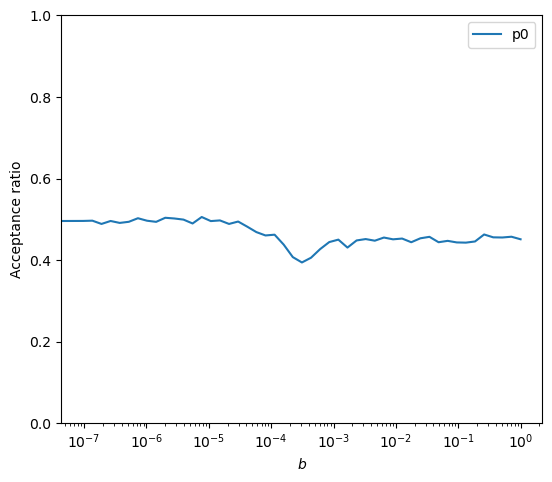

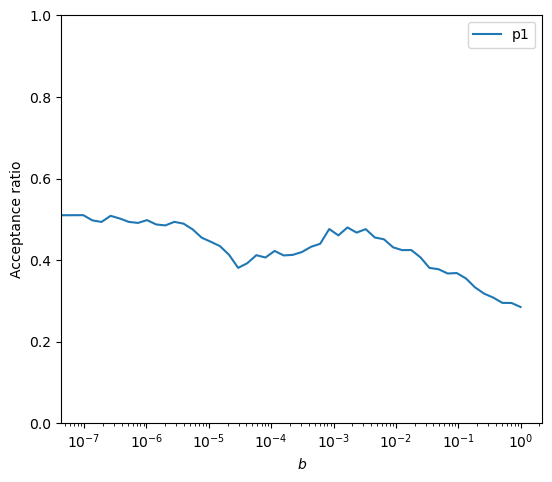

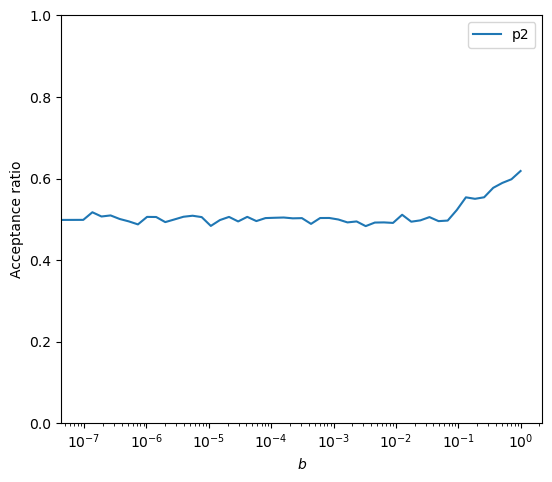

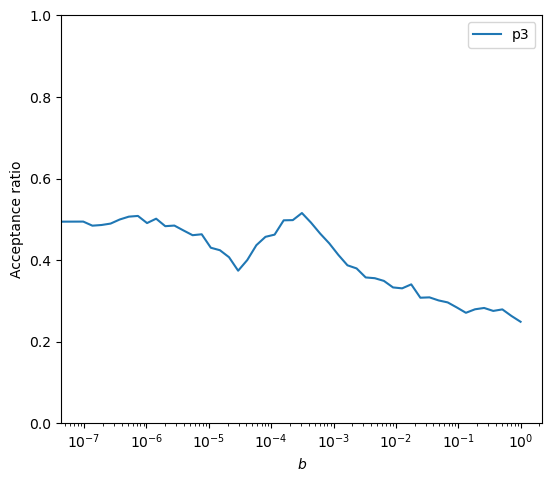

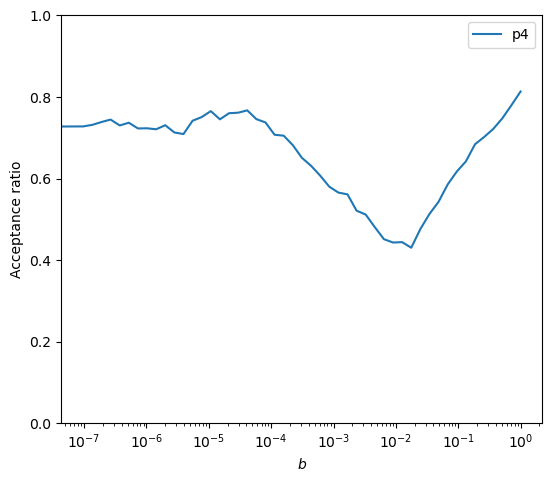

In [168]:
# 採択率のプロット
ratio_p = np.load(_dir_+"/ratio_p.npy")
print("おおむね0.2から0.8の間に収まっていれば成功。")
plt.figure(figsize=(24,12))
for i in range(num_para):
    plt.figure(figsize=(36,18))
    plt.subplot(3,5,i+1)
    plt.plot(temp,ratio_p[:,i]/(cycle-burn_in_length),label="p{}".format(i))
    plt.xscale("log")
    plt.ylim(0,1)
    plt.xlabel("$b$")
    plt.ylabel("Acceptance ratio") 
    plt.legend()
    plt.show()

収束するまでの焼きなまし区間(burn_in)が十分か確認する。


<Figure size 2400x1000 with 0 Axes>

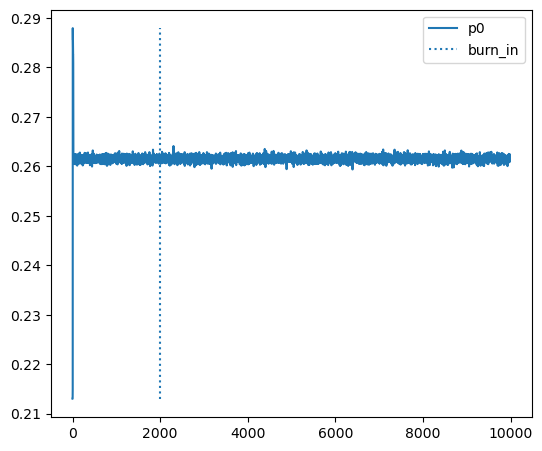

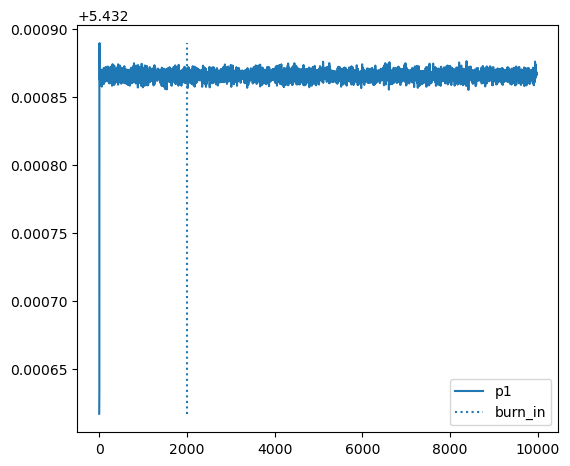

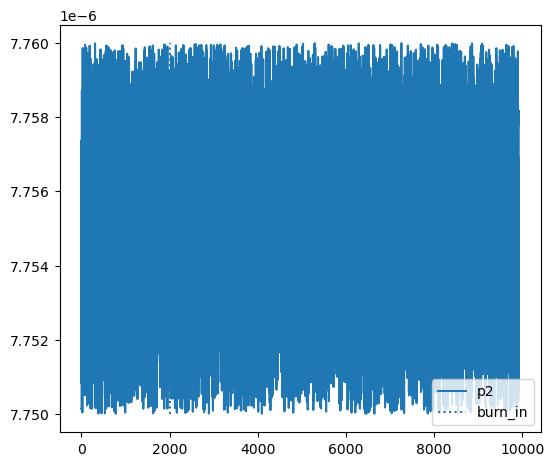

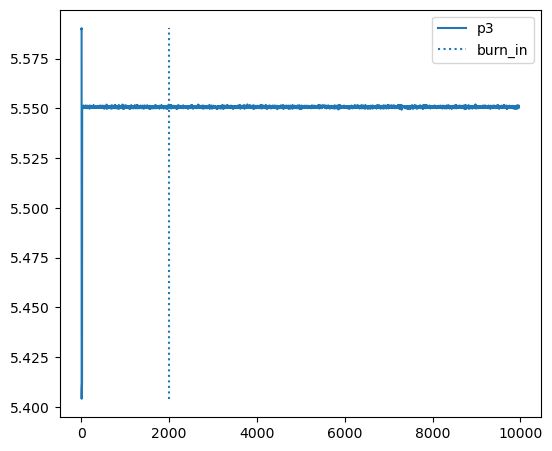

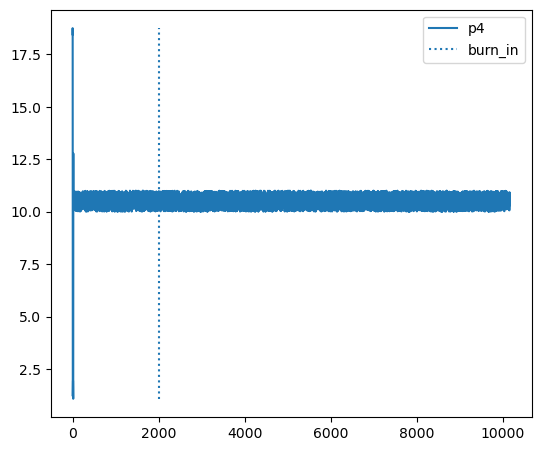

In [169]:
# 各パラメータの採択履歴をプロット
print("収束するまでの焼きなまし区間(burn_in)が十分か確認する。")
i = 49 # 履歴を確認したいレプリカのインデックス（逆温度の数が50の時は0から49までの番号）を入れる
plt.figure(figsize=(24,10))
for j in range(num_para):
    plt.figure(figsize=(36,18))
    _pp_ = np.load(_dir_+"/_rslt_p{}_.npy".format(j), allow_pickle=True)
    plt.subplot(3,5,j+1)
    plt.plot(_pp_[i],label="p{}".format(j))
    plt.vlines(burn_in_length,np.min(_pp_[i]),np.max(_pp_[i]),label="burn_in",linestyle="dotted")
    plt.legend()
    plt.show()

最高温度のレプリカ(b=0)との交換率(右の値がゼロで無いことを確認) 0.99925


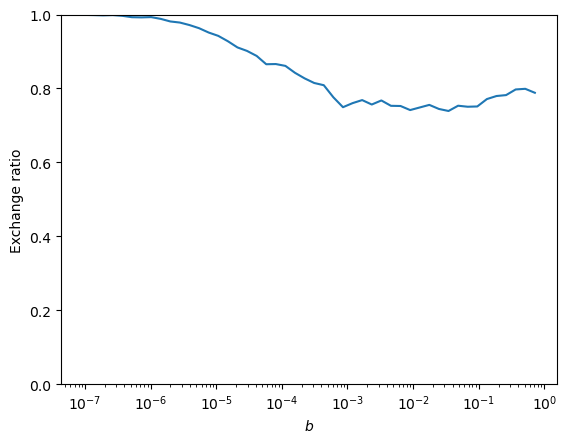

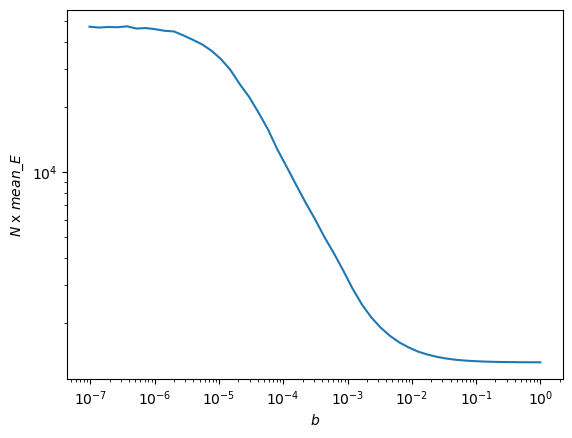

In [170]:
# レプリカ交換率とmean_Eのプロット
ratio_temp = np.load(_dir_+"/ratio_temp.npy")
mean_E = np.load(_dir_+"/mean_E.npy")
print("最高温度のレプリカ(b=0)との交換率(右の値がゼロで無いことを確認)",ratio_temp[0]/((cycle-burn_in_length)/2))
_ratio_temp_ = np.zeros((num_temp,2))
_ratio_temp_[:,0] = 1*temp
_ratio_temp_[:,1] = 1*ratio_temp/((cycle-burn_in_length)/2)
_mean_E_ = np.zeros((num_temp,2))
_mean_E_[:,0] = 1*temp
_mean_E_[:,1] = 1*mean_E/(cycle-burn_in_length)

plt.plot(temp[1:num_temp-1],ratio_temp[1:num_temp-1]/((cycle-burn_in_length)/2))
plt.xscale("log")
plt.xlabel("$b$")
plt.ylabel("Exchange ratio")
plt.ylim(0,1)
plt.show()
plt.plot(temp[1:num_temp],n*mean_E[1:num_temp]/(cycle-burn_in_length))
plt.xlabel("$b$")
plt.xscale("log")
plt.yscale("log")
plt.ylabel("$N$ x $mean$_$E$")
plt.show()

自由エネルギーの最小値 0.004575212636262348
推定されたノイズの標準偏差 3214.199700417736
最適な逆温度のインデックス 1


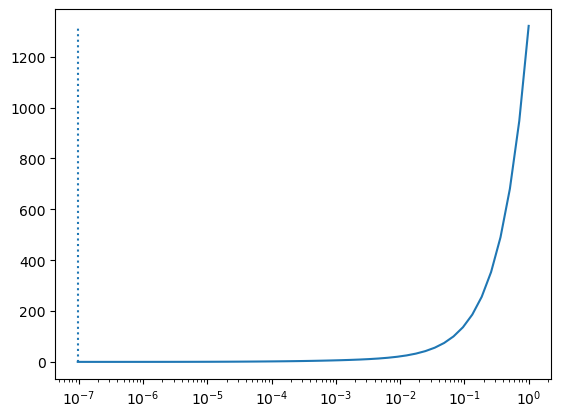

In [171]:
# ノイズ推定
F = []
for i in range(1,num_temp):
    A = 0
    for j in range(i):
        A += (temp[j+1] - temp[j])*mean_E[j+1]/(cycle-burn_in_length)*n
    F = np.append(F,A) #- n/2*(np.log(temp[i])-np.log(2*np.pi)))
plt.plot(temp[1:num_temp],F)
plt.xscale("log")
plt.vlines(temp[np.argmin(F)+1],np.min(F),np.max(F),linestyle="dotted")
#plt.yscale("log")
#plt.ylim(-200,500)
print("自由エネルギーの最小値",np.min(F))
print("推定されたノイズの標準偏差",1/(temp[np.argmin(F)+1])**0.5)
print("最適な逆温度のインデックス",np.argmin(F)+1)
plt.show()

In [172]:
F[48]

np.float64(1321.5071509273328)

<Figure size 2400x1000 with 0 Axes>

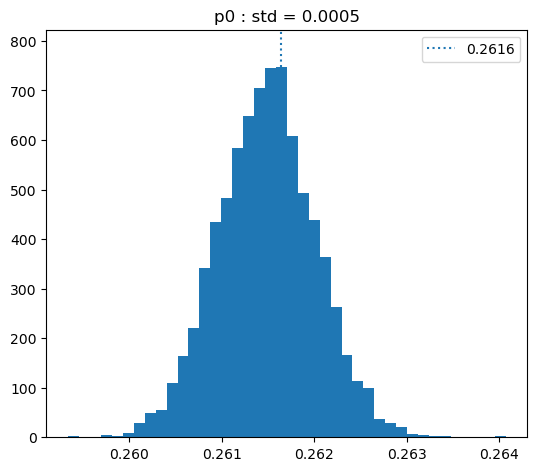

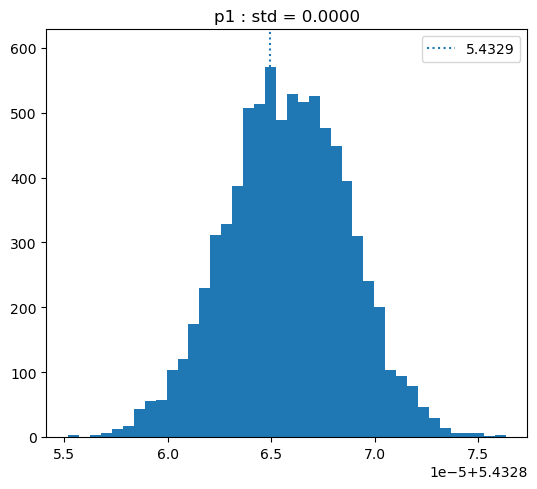

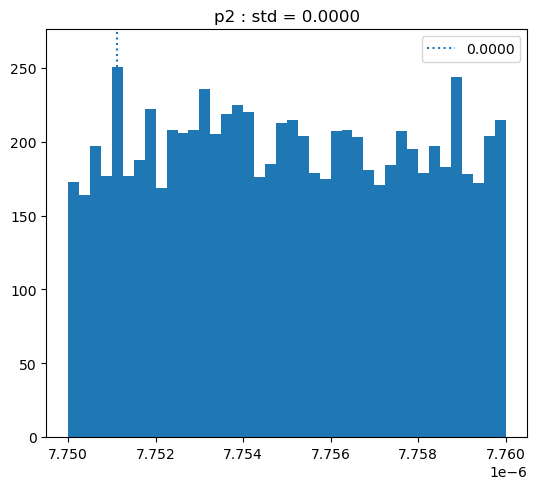

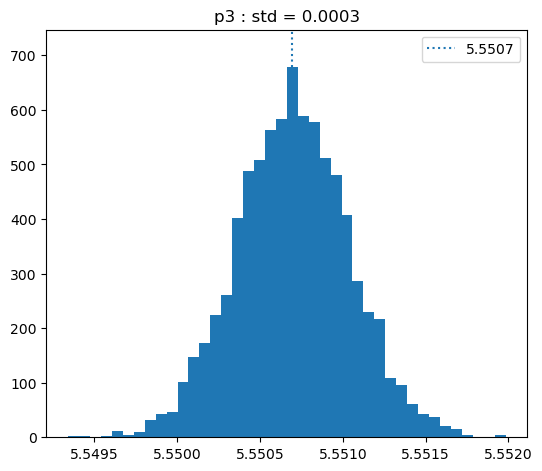

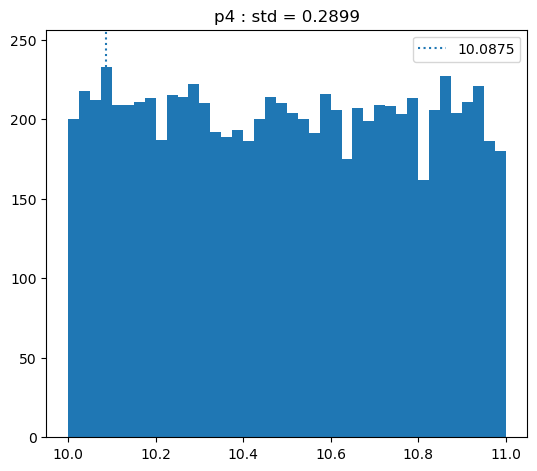

In [173]:
# 事後確率分布をプロット
i = np.argmin(F)+1 # ノイズ推定で得られた最適な逆温度のインデックスが入る
i = 49#ポアソン
_pp_MPM_ = np.zeros(num_para)
plt.figure(figsize=(24,10))
for j in range(num_para):
    plt.figure(figsize=(36,18))
    _pp_ = np.load(_dir_+"/_rslt_p{}_.npy".format(j), allow_pickle=True)
    plt.subplot(3,5,j+1)
    plt.title("p{} : std = {:.4f}".format(j,np.std((_pp_[i])[burn_in_length::])))
    plt.hist((_pp_[i])[burn_in_length::],bins=40)
    _pp_hist_ = np.histogram((_pp_[i])[burn_in_length::],bins=40)
    _pp_MPM_[j] = ((_pp_hist_[1])[np.argmax(_pp_hist_[0])+1]+(_pp_hist_[1])[np.argmax(_pp_hist_[0])])/2
    plt.vlines(_pp_MPM_[j],0,1.1*np.max(_pp_hist_[0]),linestyle="dotted",label="{:.4f}".format(_pp_MPM_[j]))
    plt.ylim(0,1.1*np.max(_pp_hist_[0]))
    plt.legend()
    plt.show()
    

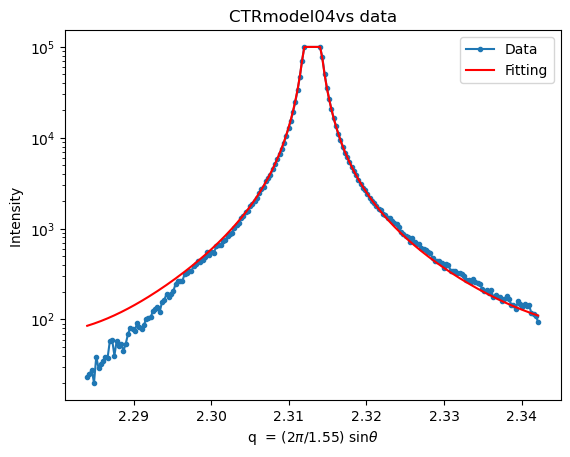

In [174]:
# パラメータごとの事後確率分布の最大値を用いたMPM(maximizer of the posterior marginal)推定によるフィッティング結果
I0  = _pp_MPM_[0]
a   = _pp_MPM_[1]
mu  = _pp_MPM_[2]
aS  = _pp_MPM_[3]
bg  = _pp_MPM_[4]

#_y_ = psV(x,mu1,w1,A1,x1) + psV(x,mu2,w2,A2,x2)
_y_ =  CTRmodel04( q_data, I0, a, mu, aS, NS ) + bg
_y_ = np.clip(_y_, None, 1e5)

q_mask = (q_data > 2.311999) & (q_data < 2.314032)
valid_idx = ~q_mask

q_data_masked = q_data[valid_idx]

plt.yscale('log') 
plt.plot(q_data_masked, y, ".-", label="Data")
plt.plot(q_data, _y_, color="r", label="Fitting")  

#plt.plot(q_data,y_fit_cut,label="org_Model")
plt.xlabel(r'q  = (2$\pi$/1.55) sin$\theta$')
plt.ylabel('Intensity ')
plt.title('CTRmodel04vs data')
plt.legend()
plt.show()
#plt.xlim(np.max(x),np.min(x))

In [175]:
_pp_MPM_

array([2.61646171e-01, 5.43286496e+00, 7.75112674e-06, 5.55069510e+00,
       1.00875316e+01])

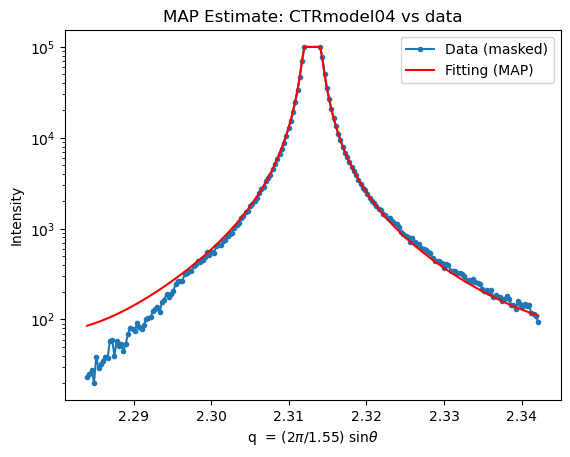

In [176]:
# MAP推定結果
_opt_j_ = 49
num_para = np.size(_p_max_)
I0   = (_optimal_[num_para*_opt_j_])[cycle]
a    = (_optimal_[num_para*_opt_j_+1])[cycle]
mu   = (_optimal_[num_para*_opt_j_+2])[cycle]
aS   = (_optimal_[num_para*_opt_j_+3])[cycle]
#Ns   = (_optimal_[num_para*_opt_j_+4])[cycle]
bg   = (_optimal_[num_para*_opt_j_+4])[cycle]

y_map = CTRmodel04(q_data, I0, a, mu, aS, NS)+bg
y_map = np.clip(y_map, None, 1e5)

q_mask = (q_data > 2.311999) & (q_data < 2.314032)
valid_idx = ~q_mask
q_data_masked = q_data[valid_idx]
y_map_masked = y_map[valid_idx]

# 画图
plt.yscale('log')
plt.plot(q_data_masked, y, ".-", label="Data (masked)")           # 蓝点（实验数据）
plt.plot(q_data, y_map, color="r", label="Fitting (MAP)")        # 红线（模型）
# plt.plot(q_data_masked, y_map_masked, color="orange", linestyle="--", label="Fitting (masked)")  # 可选

plt.xlabel(r'q  = (2$\pi$/1.55) sin$\theta$')
plt.ylabel("Intensity")
plt.title("MAP Estimate: CTRmodel04 vs data")
plt.legend()
plt.show()